<a href="https://colab.research.google.com/github/universegirlanushka/Titanic-Survival-Benchmark-Analysis./blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## California Housing Price Prediction: A Linear Regression Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

# 1. Data load karo
housing = fetch_california_housing()

# 2. DataFrame (df) mein store karo taaki table ki tarah dikhe
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)

# Target (Price) ko bhi ek column bana dete hain
df['MedHouseVal'] = housing.target

# 3. Pura data table ki form mein call karo (Pehle 5 rows)
print("--- Original Data Table ---")
print(df.head())

# 4. Standardization ka Logic (Manual Formula Use Karke)
# Hum 'MedInc' (Median Income) column par try karte hain
column_to_scale = 'MedInc'

mean_val = df[column_to_scale].mean()
std_val = df[column_to_scale].std()

# Formula Apply karna: (x - mean) / std
df[f'{column_to_scale}_Standardized'] = (df[column_to_scale] - mean_val) / std_val

# 5. Result dekhna
print(f"\n--- Data after Standardization of {column_to_scale} ---")
print(df[[column_to_scale, f'{column_to_scale}_Standardized']].head())

# Poore DataFrame ko call karna (agar tum Jupyter use kar rahi ho toh sirf 'df' likhna)
# print(df)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- STEP 6: Features (X) aur Target (y) select karo ---
# Hum abhi sirf 'MedInc_Standardized' use kar rahe hain (Simple Linear Regression)
# Agar saare features use karne hain toh poore df ko standardize karna padega
X = df[[f'{column_to_scale}_Standardized']]
y = df['MedHouseVal']

# --- STEP 7: Data Split (Train vs Test) ---
# 80% data training ke liye, 20% testing ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 8: Model Initialization & Training ---
model = LinearRegression()
model.fit(X_train, y_train) # Yahan Gradient Descent piche kaam kar raha hai

# --- STEP 9: Predictions ---
y_pred = model.predict(X_test)

# --- STEP 10: Model Analysis (Recruiter yahi dekhta hai) ---
print("\n--- Model Performance ---")
print(f"Intercept (c): {model.intercept_}")
print(f"Coefficient/Slope (m): {model.coef_[0]}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred)}")
print(f"R-squared Score: {r2_score(y_test, y_pred)}")

--- Original Data Table ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Data after Standardization of MedInc ---
   MedInc  MedInc_Standardized
0  8.3252             2.344709
1  8.3014             2.332181
2  7.2574             1.782656
3  5.6431             0.932945
4  3.8462            -0.012881

--- Model Performance ---
Intercept (c): 2.0677186405797796
Coefficient/Slope (m): 0.796668377954116
Mean Squared 

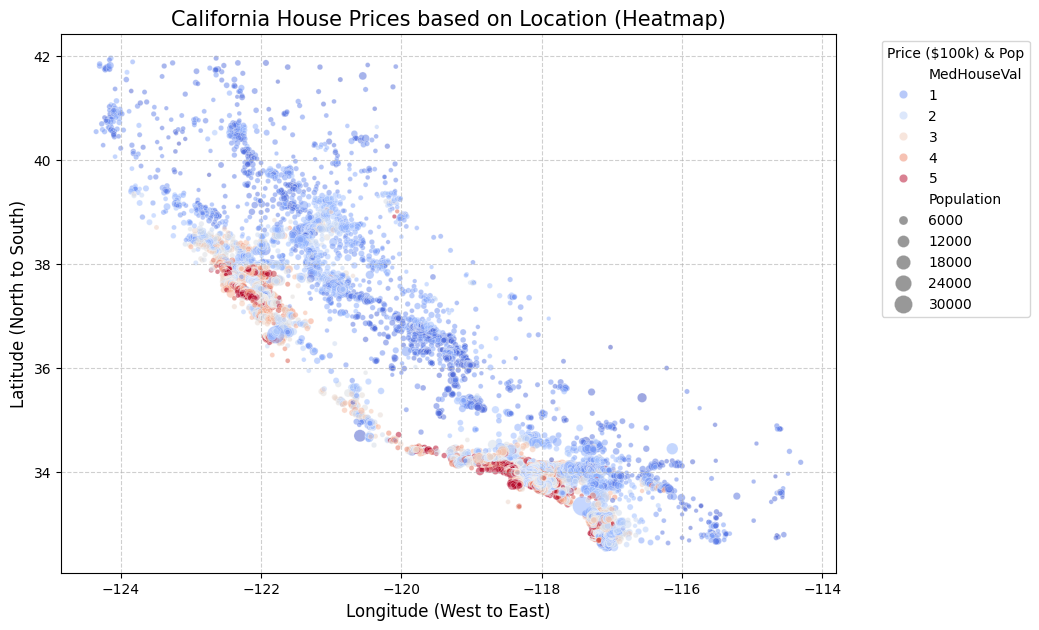

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# 1. Data load karna aur DataFrame mein store karna
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# 2. Visualization Setup (Plot ka size decide karna)
plt.figure(figsize=(10, 7))

# 3. Scatter Plot banana (Heatmap logic ke saath)
# x = Longitude (West to East position)
# y = Latitude (North to South position)
# hue = MedHouseVal (Price ke hisaab se rang badlega)
# palette = 'coolwarm' (Lal matlab mehnga, Neela matlab sasta)
# s = df['Population']/100 (Har dot ka size wahan ki population dikhayega)

heatmap = sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="MedHouseVal",
    size="Population",
    palette="coolwarm",
    alpha=0.5,           # Taaki dots thode transparent hon aur density dikhe
    sizes=(10, 200)      # Dots ke minimum aur maximum size
)

# 4. Detailing (Labeling aur Titles taaki readable ho)
plt.title("California House Prices based on Location (Heatmap)", fontsize=15)
plt.xlabel("Longitude (West to East)", fontsize=12)
plt.ylabel("Latitude (North to South)", fontsize=12)
plt.legend(title="Price ($100k) & Pop", bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Plot ko show karna
plt.grid(True, linestyle='--', alpha=0.6) # Graph par grid lines
plt.show()

/tmp/ipykernel_4631/1254989096.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index='Distance_Group', values='MedHouseVal', aggfunc='median')


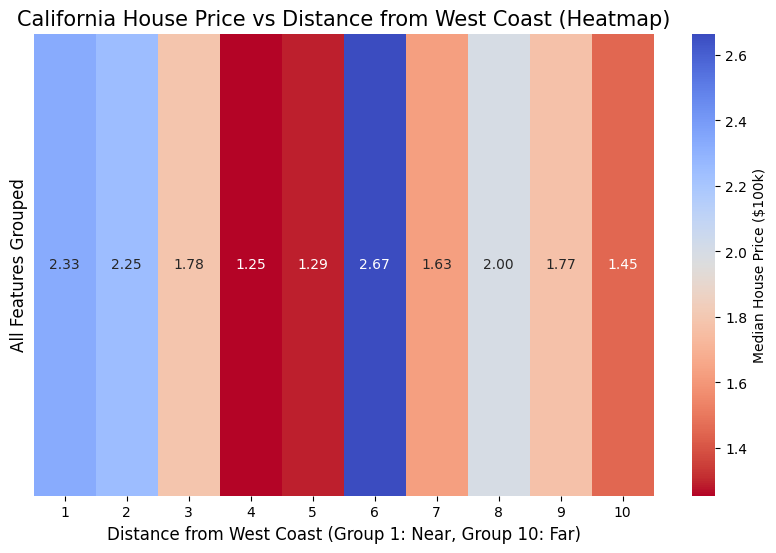

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# --- STEP 1: Data Load aur Setup ---
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target # Target (Price)

# --- STEP 2: Logic - Samundar se Doori calculate karna ---
# California ki approximate western coast line Longitude -124 ke pass hai.
# Hum har ghar ke Longitude ka distance -124 se nikalenge (abs function positive value deta hai).
coast_longitude = -124
df['Dist_from_Coast'] = abs(df['Longitude'] - coast_longitude)

# --- STEP 3: Detailing - Data Binning (Grps banana) ---
# Direct points dikhane se noise zyada hogi. Hum distance ke 10 groups (bins) banayenge.
# Qcut function equal number of data points har group mein rakhta hai.
df['Distance_Group'] = pd.qcut(df['Dist_from_Coast'], q=10, labels=[f'{i+1}' for i in range(10)])

# --- STEP 4: Analyse - Group by Price ---
# Ab hum har 'Distance_Group' ka average (median) price nikalenge.
# Isse noise hat jayegi aur clear trend dikhega.
pivot_table = df.pivot_table(index='Distance_Group', values='MedHouseVal', aggfunc='median')

# --- STEP 5: Visualization - Heatmap banana ---
plt.figure(figsize=(10, 6))

# Heatmap parameters:
# data = pivot_table (Average prices by distance)
# annot = True (Numbers bhi display honge cells ke andar)
# cmap = 'coolwarm_r' (Lal matlab mehnga, Neela matlab sasta. _r means reversed)
# fmt = '.2f' (Numbers 2 decimal places tak dikhenge)

heatmap = sns.heatmap(pivot_table.T, annot=True, cmap='coolwarm_r', fmt='.2f', cbar_kws={'label': 'Median House Price ($100k)'})

# --- STEP 6: Final Detailing ---
plt.title("California House Price vs Distance from West Coast (Heatmap)", fontsize=15)
plt.xlabel("Distance from West Coast (Group 1: Near, Group 10: Far)", fontsize=12)
plt.ylabel("All Features Grouped", fontsize=12)
plt.yticks([]) # Y-axis labels hatana kyunki sirf ek hi row hai

# Graph par grid lines
plt.show()

## Multiple Linear Regression

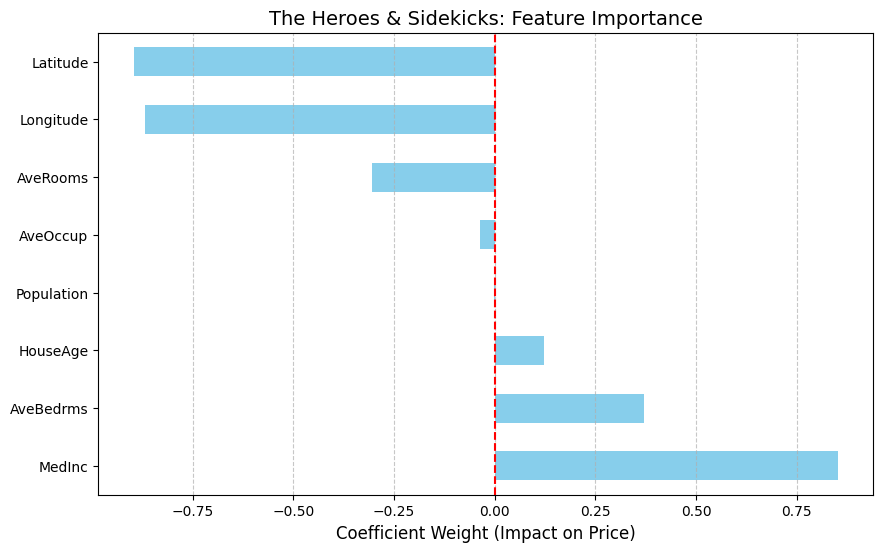

R2 Score (Accuracy): 0.5758
MSE (Error): 0.5559


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- STEP 1: Data Setup ---
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target # MedHouseVal

# --- STEP 2: Standardization (Sabko ek barabar scale par lana) ---
# Multiple features ke liye StandardScaler sabse best hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# --- STEP 3: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# --- STEP 4: Model Training ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- STEP 5: Predictions ---
y_pred = model.predict(X_test)

# --- STEP 6: Hero vs Sidekick (Coefficients Analysis) ---
# Coefficients batate hain ki har feature ka weightage kitna hai
importance = model.coef_
feature_importance = pd.Series(importance, index=X.columns).sort_values(ascending=False)

# --- STEP 7: Visualization ---
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='skyblue')
plt.title("The Heroes & Sidekicks: Feature Importance", fontsize=14)
plt.xlabel("Coefficient Weight (Impact on Price)", fontsize=12)
plt.axvline(x=0, color='red', linestyle='--') # 0 line for reference
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- STEP 8: Final Performance Check ---
print(f"R2 Score (Accuracy): {r2_score(y_test, y_pred):.4f}")
print(f"MSE (Error): {mean_squared_error(y_test, y_pred):.4f}")